# Análisis exploratorio

Micaela Gauto (Instituto Nacional de Epidemiología)  
Tamara Ricardo (Instituto Nacional de Epidemiología)

In [ ]:
knitr::opts_chunk$set(
  echo = FALSE,
  message = FALSE,
  warning = FALSE,
  fig.align = "center"
)

In [ ]:
pacman::p_load(
  epikit,
  geoAr,
  sf,
  tmap,
  apyramid,
  flextable,
  rio,
  janitor,
  tidyverse
)

In [ ]:
## AVAD por provincia, sexo y grupo etario
AVAD_prov <- import("../datos_limpios/arg_sim_avad_dm2_prov.rds")

In [ ]:
## Capas GIS provincias
shp_arg <- get_geo(geo = "ARGENTINA") |>
  # Añadir ids de provincia
  add_geo_codes() |>

  # Quitar filas vacías
  drop_na() |>

  # Cambiar etiqueta CABA
  mutate(prov_nombre = if_else(codprov_censo == "02", name_prov, name_iso)) |>

  # Crear región geográfica DEIS
  mutate(
    region_deis = case_when(
      codprov_censo %in% c("02", "06", "14", "30", "82") ~ "Centro",
      codprov_censo %in% c("18", "22", "34", "54") ~ "NEA",
      codprov_censo %in% c("38", "66") ~ "NOA1",
      codprov_censo %in% c("10", "86", "90") ~ "NOA2",
      codprov_censo %in% c("46", "50", "70", "74") ~ "Cuyo",
      .default = "Patagonia"
    )
  ) |>

  # Agrupar por provincia
  count(codprov_censo, prov_nombre, region_deis) |>

  # Validar geometría
  st_make_valid()

## Análisis espacial y tendencia de la carga de enfermedad por diabetes mellitus en Argentina, período 2005-2018

### Prevalencia DM2 y tasas específicas AVP, AVD y AVAD por sexo y grupo etario decenal, Argentina (2005-2018)

In [ ]:
## Datos AVP, AVD y AVAD por año, sexo y grupo etario
tab <- AVAD_arg |>
  # Seleccionar columnas
  select(
    Año = anio_enfr,
    "Grupo etario" = grupo_edad_10,
    sexo,
    dm2_prev:dm2_prev_upp,
    contains(c("AVP", "AVD", "AVAD"))
  ) |>

  # Crear columna prevalencia (IC)
  unite_ci(
    col = "Prev. (CI)",
    e = dm2_prev,
    l = dm2_prev_low,
    u = dm2_prev_upp,
    m100 = FALSE
  ) |>

  # Crear columna AVP (UI)
  unite_ci(
    col = "AVP (UI)",
    e = AVP,
    l = AVP_low,
    u = AVP_upp,
    m100 = FALSE
  ) |>

  # Crear columna AVD (UI)
  unite_ci(
    col = "AVD (UI)",
    e = AVD,
    l = AVD_low,
    u = AVD_upp,
    m100 = FALSE
  ) |>

  # Crear columna AVAD (UI)
  unite_ci(
    col = "AVAD (UI)",
    e = AVAD,
    l = AVAD_low,
    u = AVAD_upp,
    m100 = FALSE
  ) |>

  # Crear columna tasa AVP (UI)
  unite_ci(
    col = "Tasa AVP (UI)",
    e = AVP_tasa,
    l = AVP_tasa_low,
    u = AVP_tasa_upp,
    m100 = FALSE
  ) |>

  # Crear columna tasa AVD (UI)
  unite_ci(
    col = "Tasa AVD (UI)",
    e = AVD_tasa,
    l = AVD_tasa_low,
    u = AVD_tasa_upp,
    m100 = FALSE
  ) |>

  # Crear columna tasa AVAD (UI)
  unite_ci(
    col = "Tasa AVAD (UI)",
    e = AVAD_tasa,
    l = AVAD_tasa_low,
    u = AVAD_tasa_upp,
    m100 = FALSE
  ) |>

  # Pasar a formato wide
  pivot_wider(names_from = sexo, values_from = 4:10)


## Generar tabla
tab |>
  flextable() |>

  separate_header(split = "_") |>

  merge_v(j = 1) |>

  autofit() |>

  font(fontname = "Calibri", part = "all")

Año Grupo etario Prev. (CI) AVP (UI) Tasa AVP (UI) AVD (UI) Tasa AVD (UI) AVAD (UI) Tasa AVAD (UI) Mujer Varón Mujer Varón Mujer Varón Mujer Varón Mujer Varón Mujer Varón Mujer Varón 2005 30 a 39 0.06 (0.04-0.07) 0.03 (0.02-0.04) 50.90 (6.57-106.51) 52.56 (7.71-105.89) 1.98 (0.26-4.15) 2.05 (0.30-4.13) 9,671.42 (7276.10-12087.46) 1,090.92 (705.92-1480.26) 376.64 (283.36-470.73) 42.55 (27.53-57.74) 9,723.12 (7331.15-12139.01) 1,143.64 (756.49-1536.49) 378.65 (285.50-472.74) 44.61 (29.51-59.93) 40 a 49 0.05 (0.04-0.07) 0.05 (0.04-0.07) 177.88 (76.64-283.88) 206.29 (102.44-312.80) 7.95 (3.42-12.68) 9.63 (4.78-14.61) 6,274.83 (4594.13-7894.68) 8,537.80 (5558.34-11495.29) 280.28 (205.21-352.64) 398.67 (259.55-536.77) 6,454.40 (4769.82-8077.59) 8,741.64 (5743.48-11683.66) 288.30 (213.06-360.81) 408.19 (268.19-545.57) 50 a 59 0.11 (0.09-0.13) 0.11 (0.09-0.14) 589.24 (416.08-774.64) 834.61 (633.97-1033.00) 30.67 (21.65-40.32) 46.98 (35.69-58.15) 18,276.88 (14089.15-22441.82) 28,035.09 (21425.72-34648.14) 951.20 (733.25-1167.96) 1,578.08 (1206.04-1950.32) 18,861.05 (14681.86-23043.87) 28,878.71 (22231.11-35473.17) 981.60 (764.10-1199.29) 1,625.56 (1251.37-1996.76) 60 a 69 0.18 (0.15-0.22) 0.18 (0.14-0.22) 1,339.10 (1080.28-1596.91) 1,664.37 (1389.76-1943.43) 92.92 (74.96-110.81) 135.37 (113.04-158.07) 32,768.90 (25620.61-39901.52) 42,100.68 (32906.92-51510.03) 2,273.84 (1777.82-2768.78) 3,424.28 (2676.50-4189.59) 34,099.30 (26918.45-41290.55) 43,771.93 (34540.85-53189.73) 2,366.16 (1867.88-2865.17) 3,560.21 (2809.39-4326.21) 70 a 79 0.14 (0.11-0.18) 0.16 (0.12-0.20) 2,150.50 (1820.53-2474.02) 2,392.09 (2052.34-2729.58) 197.04 (166.81-226.68) 315.69 (270.85-360.23) 25,310.73 (18836.53-31857.97) 34,818.93 (24688.88-45023.34) 2,319.11 (1725.91-2919.01) 4,595.16 (3258.27-5941.87) 27,455.52 (20994.86-34000.86) 37,207.20 (27125.41-47472.54) 2,515.63 (1923.67-3115.35) 4,910.35 (3579.83-6265.10) 80+ 0.12 (0.08-0.16) 0.21 (0.11-0.31) 1,671.78 (1428.67-1913.93) 852.06 (691.05-1014.94) 310.29 (265.17-355.24) 322.71 (261.73-384.40) 10,380.56 (6437.90-14306.28) 24,557.72 (11462.29-38044.85) 1,926.69 (1194.91-2655.33) 9,301.04 (4341.25-14409.18) 12,049.60 (8096.24-15977.72) 25,420.65 (12318.70-38874.36) 2,236.48 (1502.71-2965.56) 9,627.87 (4665.61-14723.35) 2009 30 a 39 0.07 (0.06-0.08) 0.04 (0.03-0.05) 72.46 (11.86-140.31) 58.55 (8.79-115.72) 2.56 (0.42-4.95) 2.11 (0.32-4.16) 11,131.13 (9076.43-13142.34) 1,391.46 (1058.97-1727.96) 392.56 (320.09-463.49) 50.08 (38.11-62.19) 11,209.22 (9148.71-13209.35) 1,450.19 (1112.29-1794.04) 395.31 (322.64-465.85) 52.19 (40.03-64.56) 40 a 49 0.09 (0.07-0.10) 0.06 (0.05-0.08) 173.12 (71.92-272.68) 189.34 (89.50-289.99) 7.51 (3.12-11.82) 8.61 (4.07-13.18) 11,081.17 (9109.13-13033.71) 10,029.51 (7867.52-12114.02) 480.41 (394.92-565.06) 455.96 (357.67-550.73) 11,253.15 (9299.51-13203.70) 10,217.31 (8048.66-12311.63) 487.87 (403.17-572.43) 464.50 (365.91-559.71) 50 a 59 0.11 (0.09-0.13) 0.12 (0.10-0.14) 573.11 (399.69-748.62) 733.19 (549.65-914.65) 28.86 (20.12-37.69) 39.70 (29.76-49.52) 20,255.48 (16974.92-23465.14) 29,231.73 (24007.43-34351.28) 1,019.84 (854.66-1181.44) 1,582.65 (1299.80-1859.83) 20,817.01 (17566.39-24052.08) 29,977.61 (24759.39-35083.81) 1,048.11 (884.44-1210.99) 1,623.04 (1340.51-1899.49) 60 a 69 0.17 (0.15-0.19) 0.17 (0.15-0.20) 1,159.56 (918.10-1395.29) 1,496.36 (1240.63-1754.55) 75.50 (59.78-90.85) 113.10 (93.77-132.62) 37,031.06 (31706.16-42385.83) 44,347.66 (36568.64-52195.14) 2,411.27 (2064.54-2759.95) 3,352.06 (2764.08-3945.22) 38,212.57 (32904.19-43554.23) 45,837.21 (38064.95-53702.86) 2,488.21 (2142.55-2836.03) 3,464.65 (2877.18-4059.18) 70 a 79 0.17 (0.14-0.20) 0.21 (0.18-0.25) 1,780.82 (1492.61-2069.86) 1,984.39 (1686.68-2283.38) 168.80 (141.48-196.19) 261.23 (222.04-300.59) 30,083.69 (25030.80-35025.84) 47,243.51 (38042.99-56157.49) 2,851.50 (2372.56-3319.95) 6,219.29 (5008.11-7392.76) 31,847.13 (26812.00-36813.15) 49,238.20 (40058.61-58093.35) 3,018.65 (2541.39-3489.36) 6,481.88 (527

### Tasas estandarizadas AVP, AVD y AVAD por año y sexo

In [ ]:
## Datos para la tabla
AVAD_te_arg |>
  # Renombrar columnas
  rename(Año = anio_enfr) |>

  # Crear columna tasa AVP (UI)
  unite_ci(
    col = "Tasa AVP (UI)",
    e = AVP_tasa_std,
    l = AVP_tasa_std_low,
    u = AVP_tasa_std_upp,
    m100 = FALSE
  ) |>

  # Crear columna tasa AVD (UI)
  unite_ci(
    col = "Tasa AVD (UI)",
    e = AVD_tasa_std,
    l = AVD_tasa_std_low,
    u = AVD_tasa_std_upp,
    m100 = FALSE
  ) |>

  # Crear columna tasa AVAD (UI)
  unite_ci(
    col = "Tasa AVAD (UI)",
    e = AVAD_tasa_std,
    l = AVAD_tasa_std_low,
    u = AVAD_tasa_std_upp,
    m100 = FALSE
  ) |>

  # Pasar a formato wide
  pivot_wider(names_from = sexo, values_from = c(3:5)) |>

  ## Generar tabla
  flextable() |>

  # Formato de tabla
  merge_v(j = 1) |>

  autofit() |>

  separate_header(split = "_") |>

  font(fontname = "Calibri", part = "all")

Año Tasa AVP (UI) Tasa AVD (UI) Tasa AVAD (UI) Mujer Varón Mujer Varón Mujer Varón 2005 61.41 (55.98-66.72) 68.76 (62.90-74.81) 1,039.22 (922.57-1155.30) 1,617.33 (1368.77-1870.48) 1,100.98 (983.20-1217.88) 1,686.00 (1437.32-1939.29) 2009 51.85 (46.99-56.75) 57.62 (52.17-62.94) 1,203.36 (1113.12-1294.97) 1,704.04 (1534.13-1871.56) 1,255.07 (1164.85-1347.53) 1,762.00 (1591.94-1928.78) 2013 47.35 (42.87-51.79) 54.75 (49.90-59.67) 1,193.80 (1078.10-1307.36) 1,524.18 (1350.05-1702.08) 1,241.15 (1125.60-1354.39) 1,579.04 (1405.16-1755.88) 2018 45.68 (41.55-49.80) 56.52 (51.75-61.19) 1,345.82 (1246.44-1445.46) 2,066.28 (1867.86-2266.34) 1,391.41 (1292.16-1491.47) 2,123.13 (1924.31-2323.14)

### Pirámide AVAD por sexo y grupo etario decenal, Argentina (2005-2018)

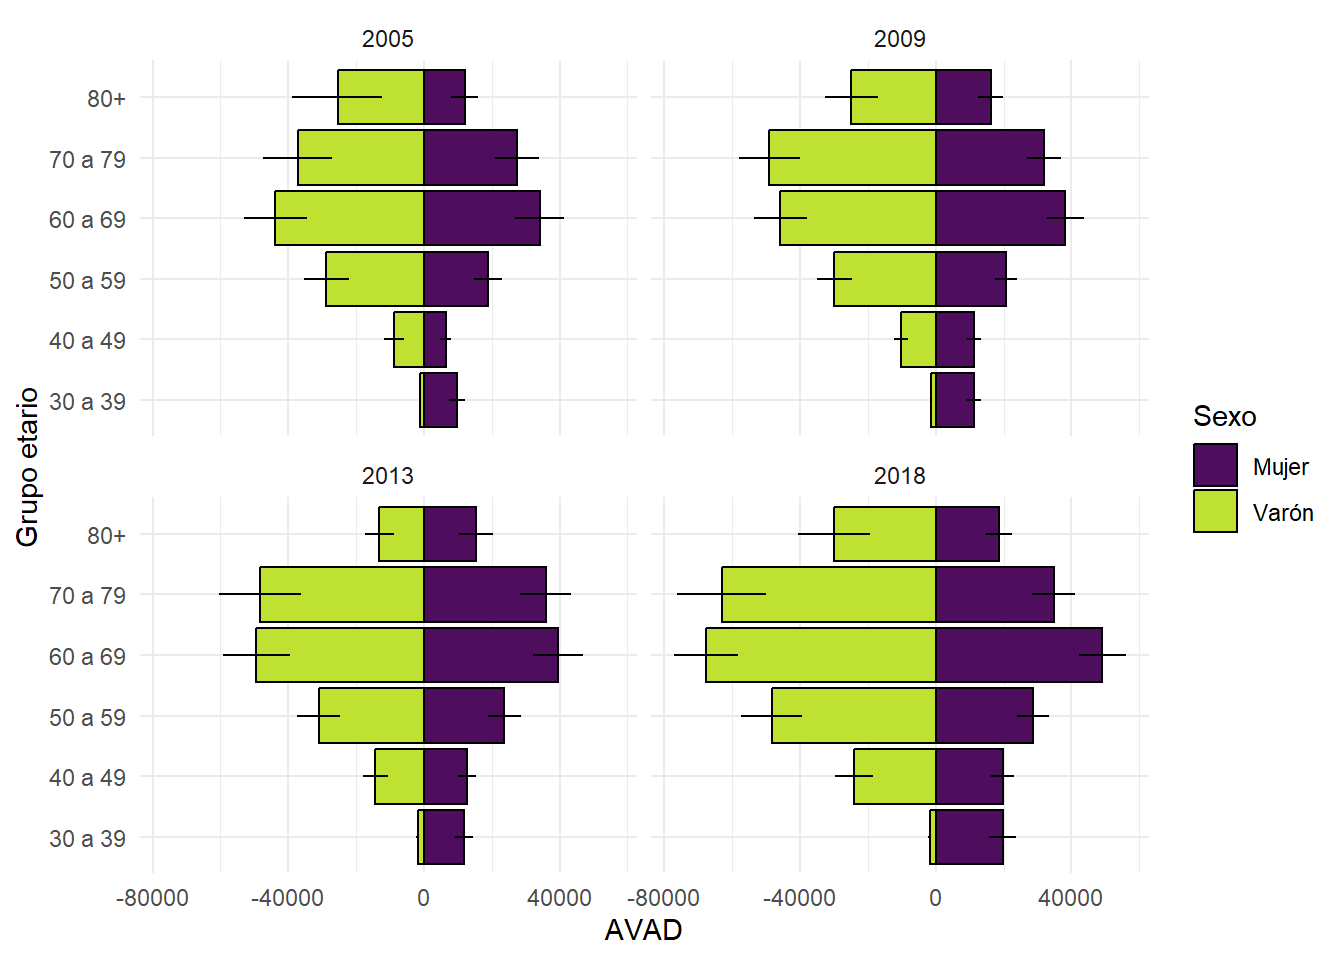

In [ ]:
## Datos para el gráfico
tab <- AVAD_arg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = where(is.numeric),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional con barras de error
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD, fill = sexo)) +
  geom_col(color = "black") +
  geom_linerange(aes(ymin = AVAD_low, ymax = AVAD_upp)) +

  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  labs(x = "Grupo etario", fill = "Sexo") +
  coord_flip() +
  facet_wrap(~anio_enfr) +
  theme_minimal()

### Pirámide tasa AVAD por sexo y grupo etario decenal, Argentina (2005-2018)

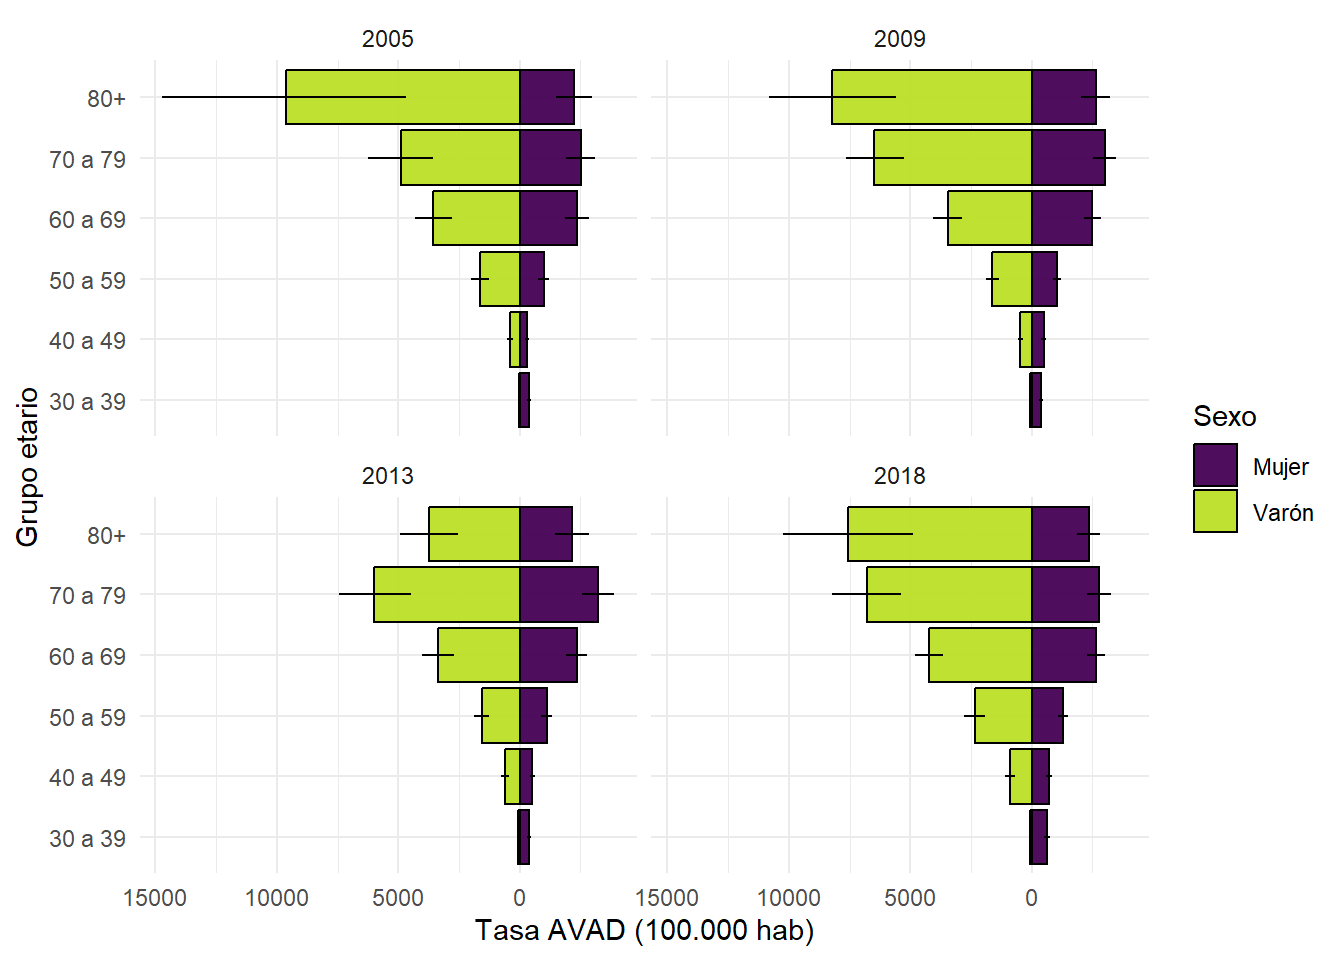

In [ ]:
## Pirámide poblacional con barras de error
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD_tasa, fill = sexo)) +
  geom_col(color = "black") +
  geom_linerange(aes(ymin = AVAD_tasa_low, ymax = AVAD_tasa_upp)) +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs) +
  coord_flip() +
  labs(x = "Grupo etario", y = "Tasa AVAD (100.000 hab)", fill = "Sexo") +
  facet_wrap(~anio_enfr) +
  theme_minimal()

### Pirámide AVAD por región, sexo y grupo etario decenal, Argentina (2005-2018)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.

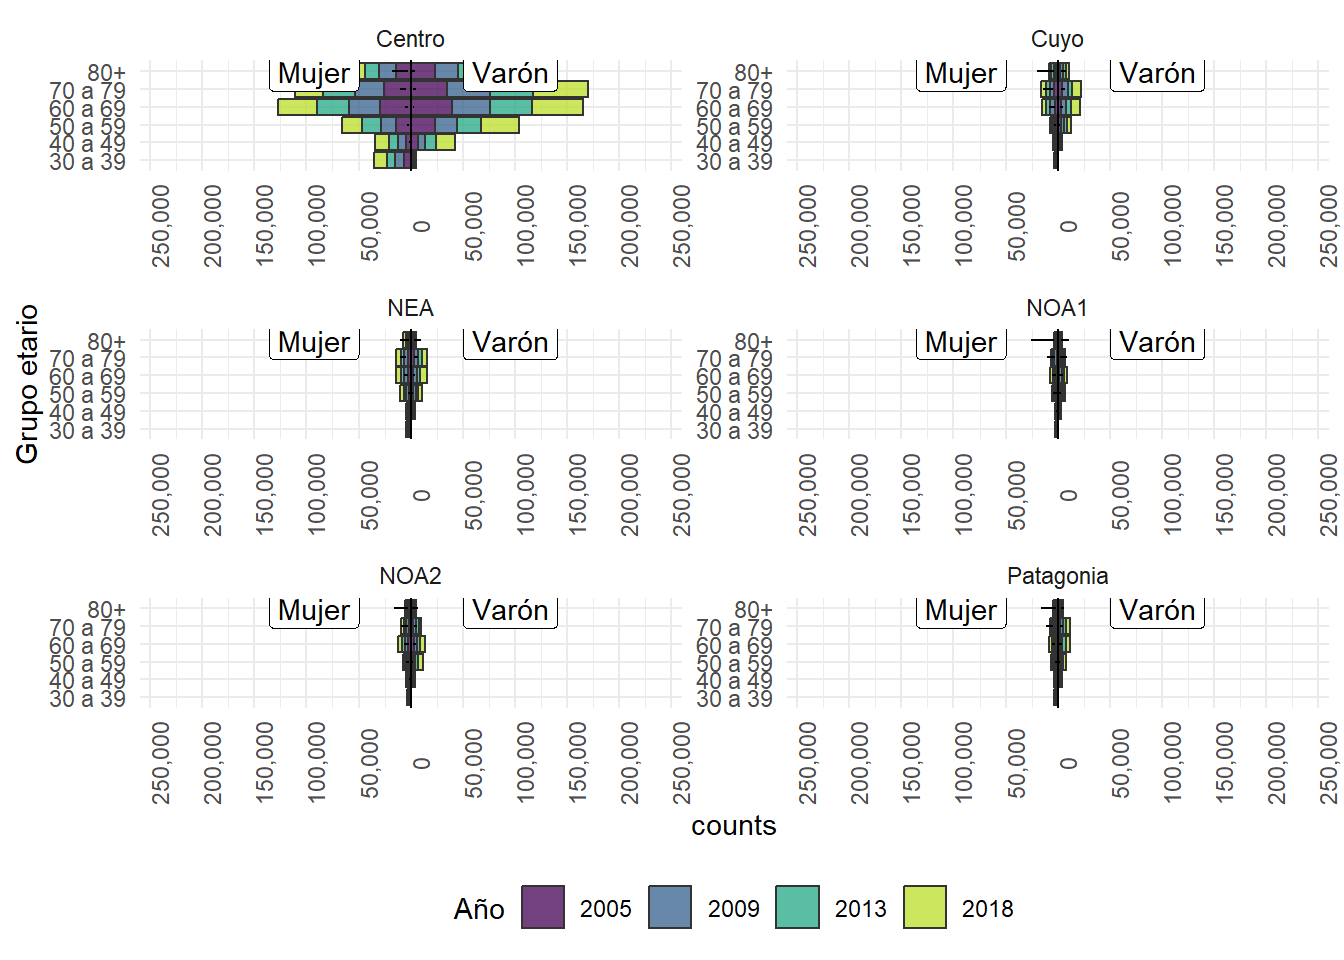

In [ ]:
## Datos para el gráfico
tab <- AVAD_reg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = contains(c("_low", "_upp")),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional
tab |>
  age_pyramid(
    age_group = grupo_edad_10,
    split_by = sexo,
    stack_by = anio_enfr,
    count = AVAD,
    show_midpoint = FALSE
  ) +
  geom_linerange(aes(ymin = AVAD_tasa_low, ymax = AVAD_tasa_upp)) +
  facet_wrap(~region_deis, scales = "free", ncol = 2) +
  scale_fill_viridis_d(end = 0.9, alpha = 0.75) +
  labs(x = "Grupo etario", fill = "Año") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90), legend.position = "bottom")

### Mapa tasa estandarizada AVP por año y provincia, Argentina (2005-2018)

Joining with `by = join_by(codprov_censo, prov_nombre)`

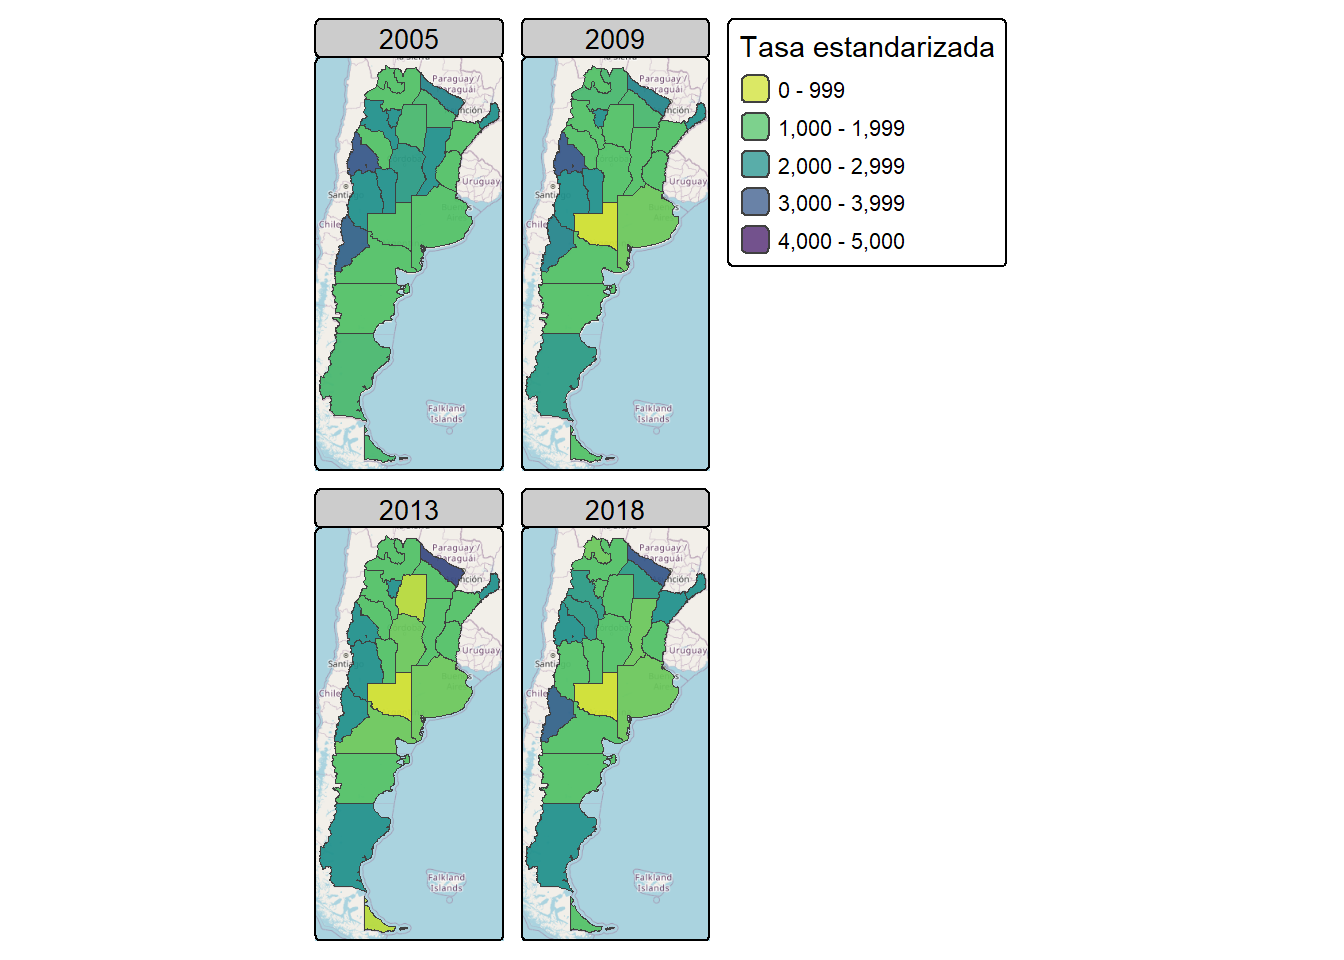

In [ ]:
## Crear objeto espacial
shp_avad <- shp_arg |>
  left_join(AVAD_te_prov)

### Mapa tasa estandarizada AVD por año y provincia, Argentina (2005-2018)

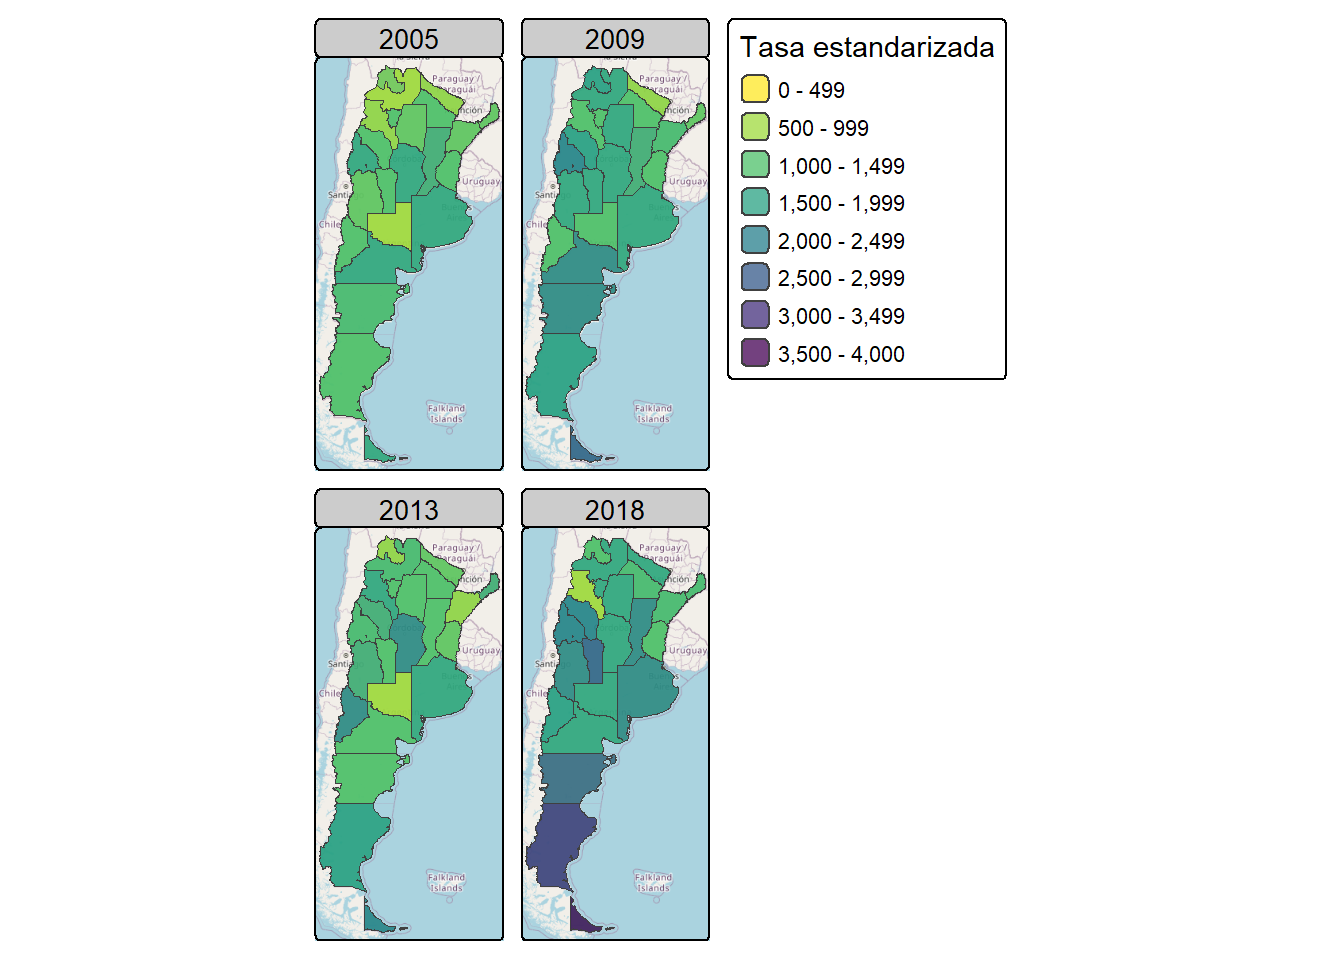

In [ ]:
tm_basemap(server = "OpenStreetMap") +
  tm_shape(shp = shp_avad) +
  tm_polygons(
    fill = "AVD_tasa_std",
    fill.scale = tm_scale(values = "-viridis"),
    fill_alpha = 0.75,
    fill.legend = tm_legend(title = "Tasa estandarizada")
  ) +
  tm_facets(by = "anio_enfr", ncol = 2)

### Mapa tasa estandarizada AVAD por año y provincia, Argentina (2005-2018)

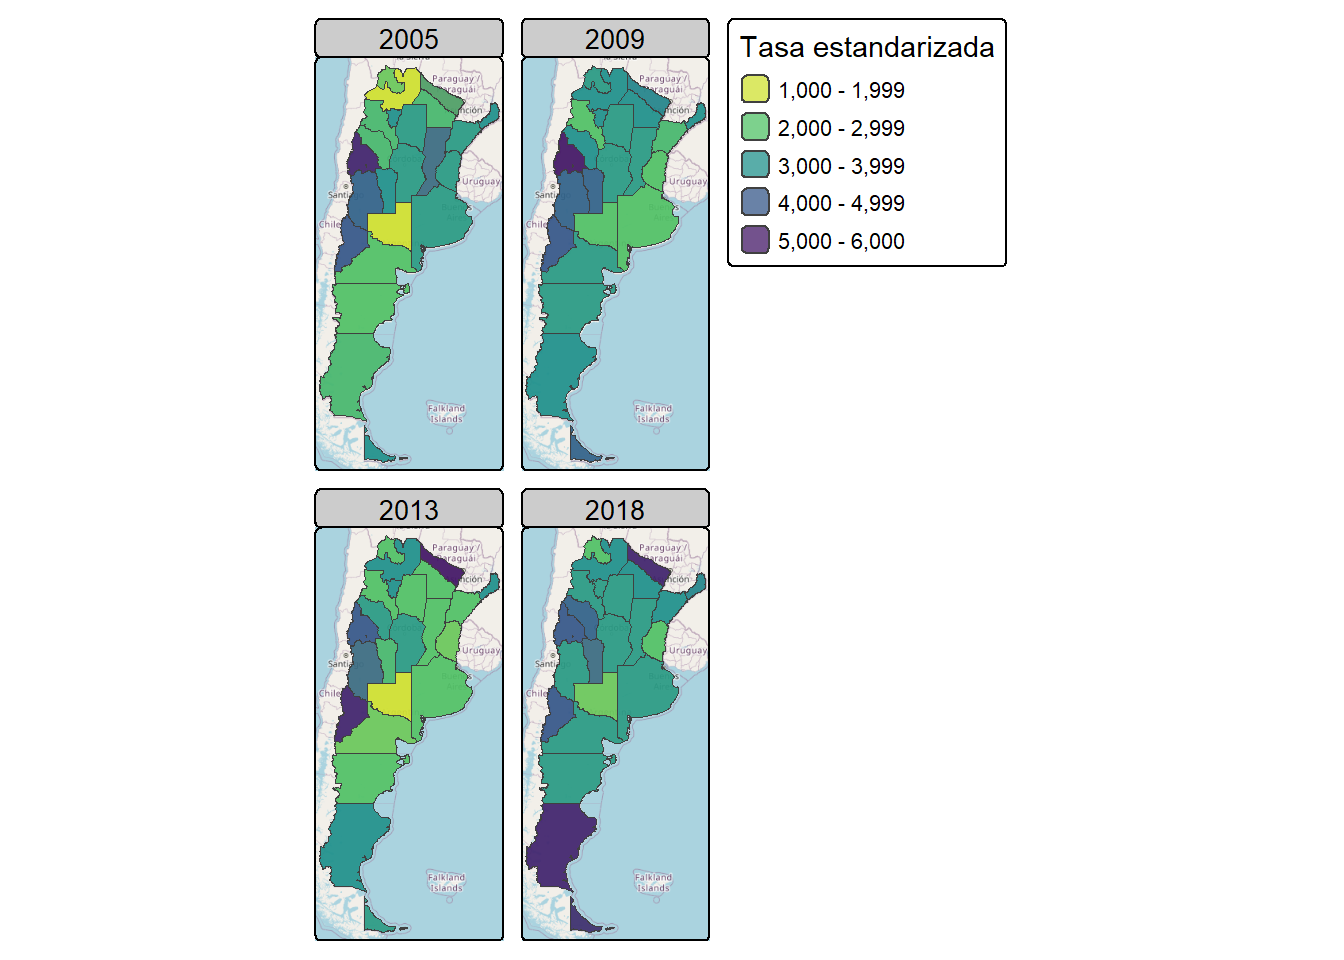

In [ ]:
tm_basemap(server = "OpenStreetMap") +
  tm_shape(shp = shp_avad) +
  tm_polygons(
    fill = "AVAD_tasa_std",
    fill.scale = tm_scale(values = "-viridis"),
    fill_alpha = 0.75,
    fill.legend = tm_legend(title = "Tasa estandarizada")
  ) +
  tm_facets(by = "anio_enfr", ncol = 2)

### Mapa tasa estandarizada AVP por año y región DEIS, Argentina (2005-2018)

Joining with `by = join_by(region_deis)`

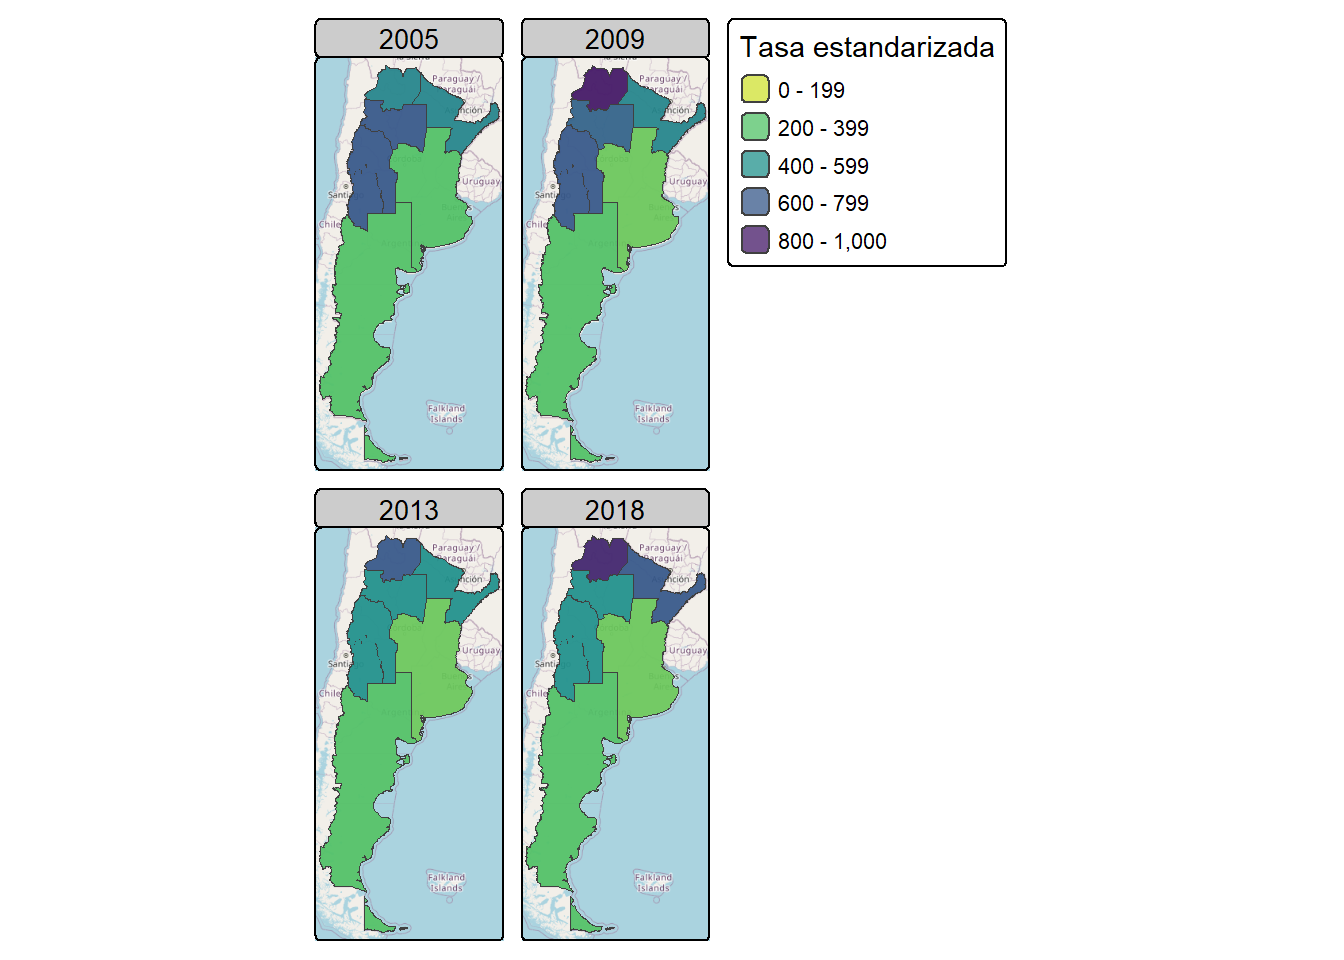

In [ ]:
## Crear objeto espacial
shp_avad <- shp_arg |>
  count(region_deis) |>
  left_join(AVAD_te_reg)

### Mapa tasa estandarizada AVD por año y región DEIS, Argentina (2005-2018)

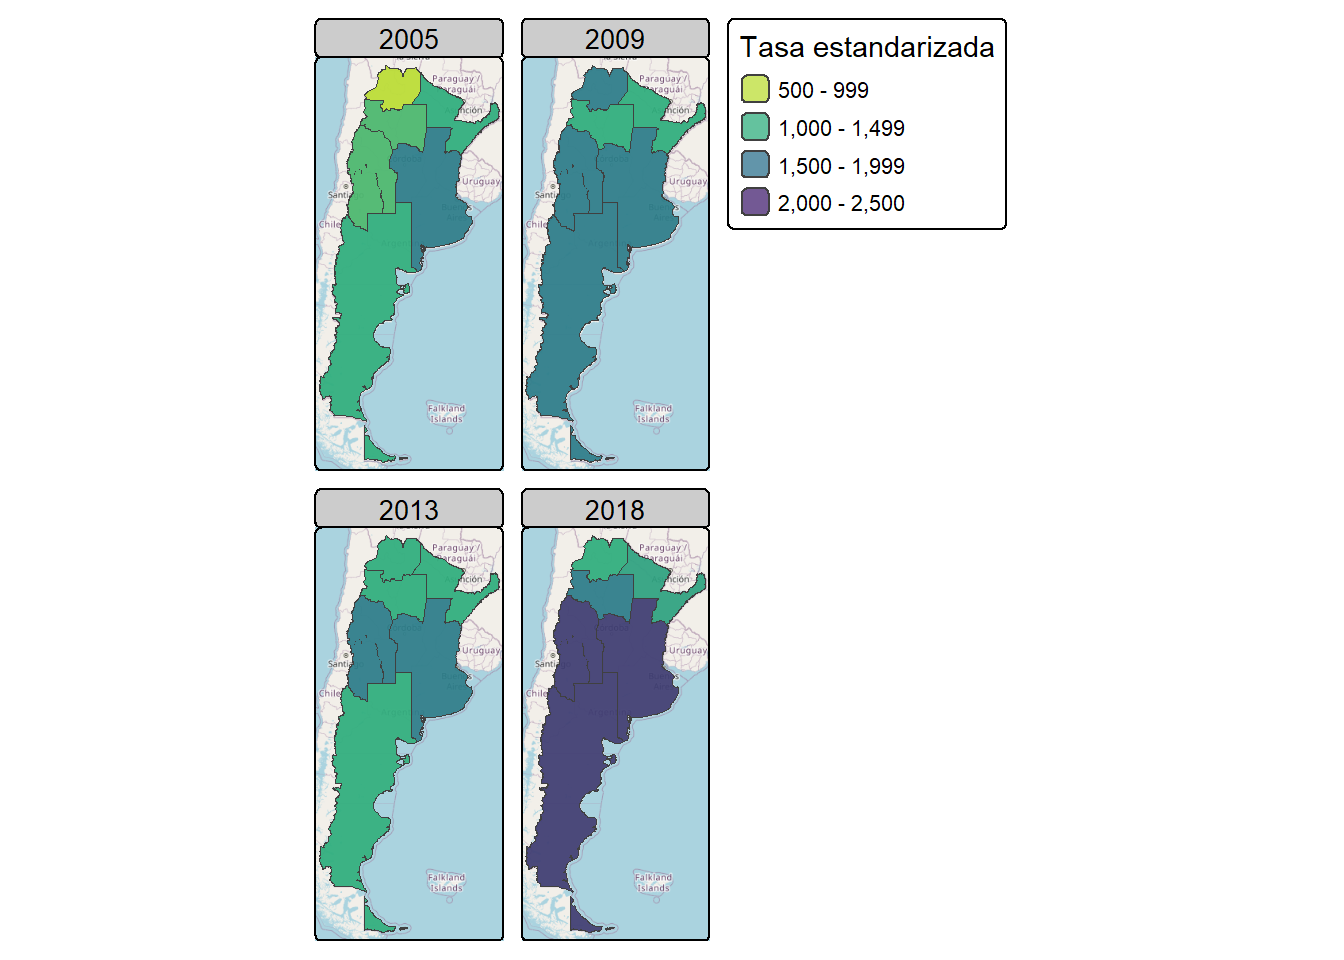

In [ ]:
tm_basemap(server = "OpenStreetMap") +
  tm_shape(shp = shp_avad) +
  tm_polygons(
    fill = "AVD_tasa_std",
    fill.scale = tm_scale(values = "-viridis"),
    fill_alpha = 0.75,
    fill.legend = tm_legend(title = "Tasa estandarizada")
  ) +
  tm_facets(by = "anio_enfr", ncol = 2)

### Mapa tasa estandarizada AVAD por año y región DEIS, Argentina (2005-2018)

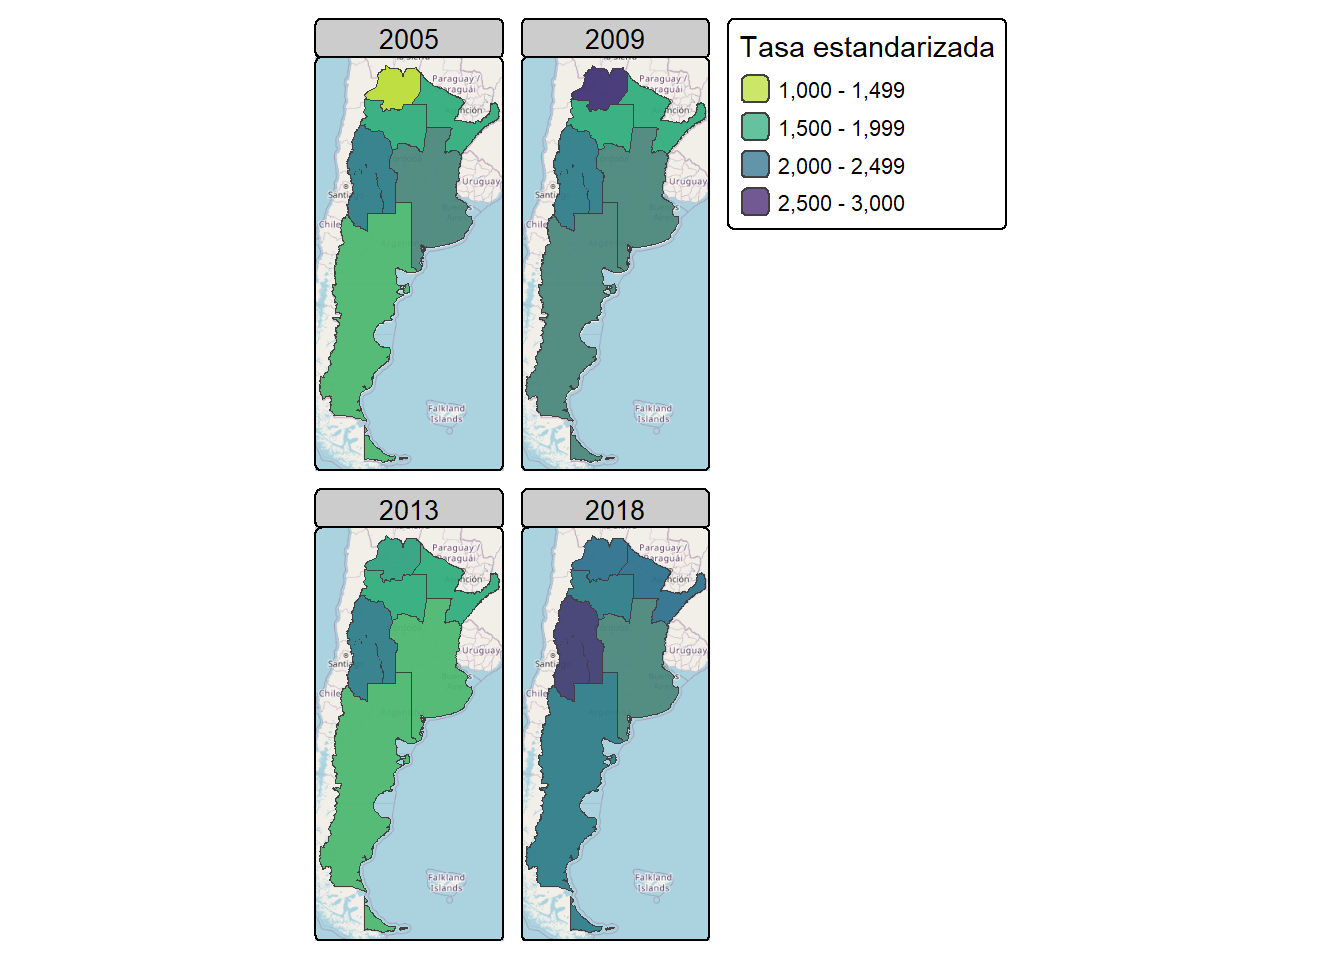

In [ ]:
tm_basemap(server = "OpenStreetMap") +
  tm_shape(shp = shp_avad) +
  tm_polygons(
    fill = "AVAD_tasa_std",
    fill.scale = tm_scale(values = "-viridis"),
    fill_alpha = 0.75,
    fill.legend = tm_legend(title = "Tasa estandarizada")
  ) +
  tm_facets(by = "anio_enfr", ncol = 2)